# PREDICTING URBAN TRAFFIC STRESS USING MACHINE LEARNING

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn import linear_model
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [2]:
data=pd.read_csv("smart_city_traffic_stress_dataset.csv")
data

,traffic_density,horn_events_per_min,avg_speed,signal_wait_time,weather_condition,road_quality_score,driver_experience_level,stress_index
0,112,12.93,28.61,56.58,Foggy,7.31,Intermediate,68.37
1,61,7.43,54.22,35.64,Rainy,8.78,Beginner,47.14
2,102,11.07,41.42,54.61,Clear,8.34,Intermediate,55.02
3,24,1.54,69.86,16.09,Clear,6.29,Expert,22.71
4,116,11.60,33.01,62.51,Clear,8.19,Expert,49.91
...,...,...,...,...,...,...,...,...
49995,19,3.65,74.20,21.97,Clear,5.96,Intermediate,27.16
49996,72,12.05,61.39,44.49,Foggy,3.29,Intermediate,57.83
49997,11,0.00,69.61,14.27,Clear,6.88,Beginner,31.10
49998,45,9.87,66.66,28.47,Clear,5.82,Intermediate,33.20


### Data Understanding

In [3]:
data.shape

(50000, 8)

In [4]:
data.columns

Index(['traffic_density', 'horn_events_per_min', 'avg_speed',
       'signal_wait_time', 'weather_condition', 'road_quality_score',
       'driver_experience_level', 'stress_index'],
      dtype='str')

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   traffic_density          50000 non-null  int64  
 1   horn_events_per_min      50000 non-null  float64
 2   avg_speed                50000 non-null  float64
 3   signal_wait_time         50000 non-null  float64
 4   weather_condition        50000 non-null  str    
 5   road_quality_score       50000 non-null  float64
 6   driver_experience_level  50000 non-null  str    
 7   stress_index             50000 non-null  float64
dtypes: float64(5), int64(1), str(2)
memory usage: 3.7 MB


In [6]:
data.head()

,traffic_density,horn_events_per_min,avg_speed,signal_wait_time,weather_condition,road_quality_score,driver_experience_level,stress_index
0,112,12.93,28.61,56.58,Foggy,7.31,Intermediate,68.37
1,61,7.43,54.22,35.64,Rainy,8.78,Beginner,47.14
2,102,11.07,41.42,54.61,Clear,8.34,Intermediate,55.02
3,24,1.54,69.86,16.09,Clear,6.29,Expert,22.71
4,116,11.60,33.01,62.51,Clear,8.19,Expert,49.91


In [7]:
data.tail()

,traffic_density,horn_events_per_min,avg_speed,signal_wait_time,weather_condition,road_quality_score,driver_experience_level,stress_index
49995,19,3.65,74.20,21.97,Clear,5.96,Intermediate,27.16
49996,72,12.05,61.39,44.49,Foggy,3.29,Intermediate,57.83
49997,11,0.00,69.61,14.27,Clear,6.88,Beginner,31.10
49998,45,9.87,66.66,28.47,Clear,5.82,Intermediate,33.20
49999,66,7.56,55.76,44.20,Clear,9.75,Expert,28.28


In [8]:
data.describe()

,traffic_density,horn_events_per_min,avg_speed,signal_wait_time,road_quality_score,stress_index
count,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,64.42008,8.820749,54.256998,37.202482,6.940413,44.402318
std,31.72428,4.378499,13.647305,16.142846,1.885609,16.351604
min,10.00000,0.000000,13.860000,5.000000,1.000000,0.000000
25%,37.00000,5.540000,43.260000,23.360000,5.650000,31.620000
50%,64.00000,8.715000,54.250000,37.260000,7.000000,43.670000
75%,92.00000,11.910000,65.280000,50.880000,8.350000,56.270000
max,119.00000,24.860000,90.000000,74.500000,10.000000,100.000000


In [9]:
data.isnull().sum()

traffic_density            0
horn_events_per_min        0
avg_speed                  0
signal_wait_time           0
weather_condition          0
road_quality_score         0
driver_experience_level    0
stress_index               0
dtype: int64

### Target Variable Distribution

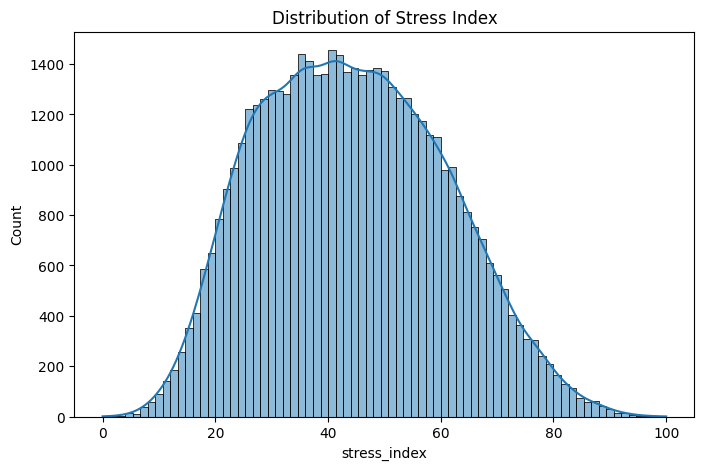

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(data['stress_index'], kde=True)
plt.title("Distribution of Stress Index")
plt.show()

### Numerical Feature Distributions

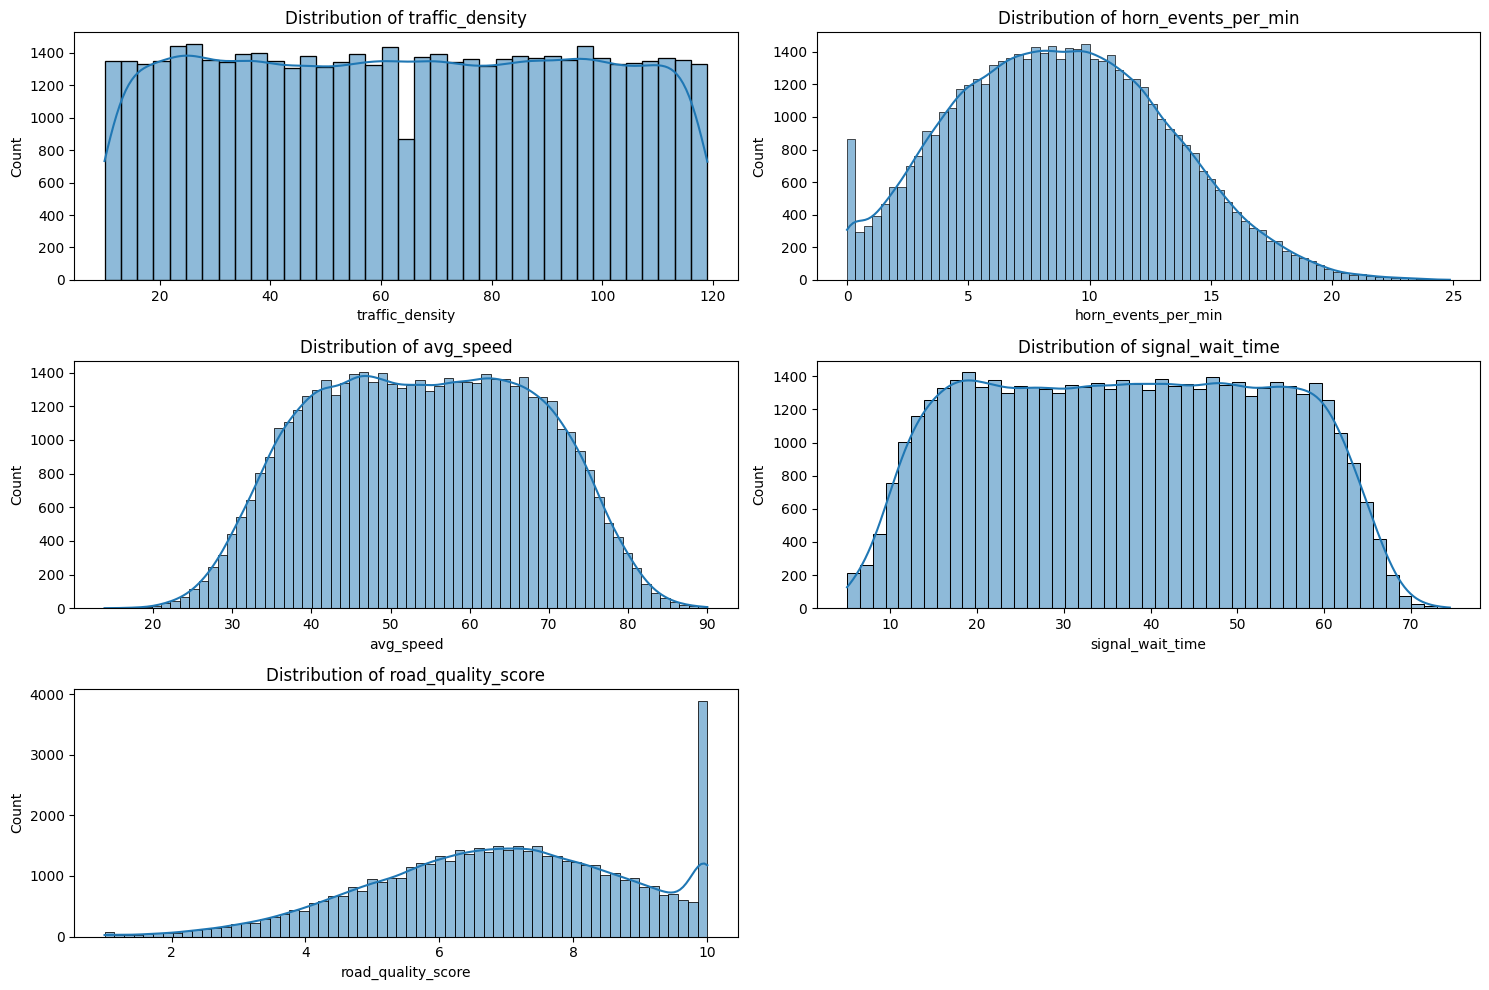

In [11]:
numerical_cols = [
    'traffic_density',
    'horn_events_per_min',
    'avg_speed',
    'signal_wait_time',
    'road_quality_score'
]

plt.figure(figsize=(15,10))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 2, i)
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

### Categorical Feature Analysis

In [12]:
print(data['weather_condition'].value_counts())
print(data['driver_experience_level'].value_counts())

weather_condition
Clear    25018
Rainy    12283
Foggy     7615
Hot       5084
Name: count, dtype: int64
driver_experience_level
Intermediate    24980
Beginner        14872
Expert          10148
Name: count, dtype: int64


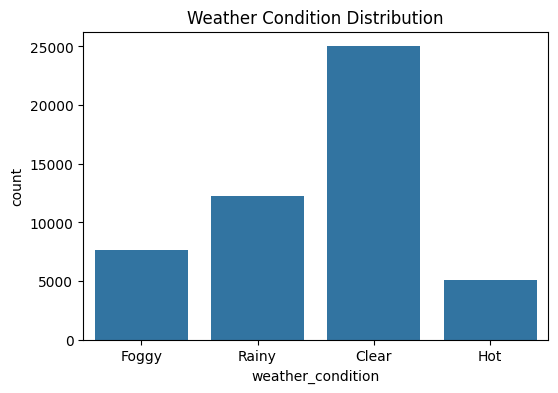

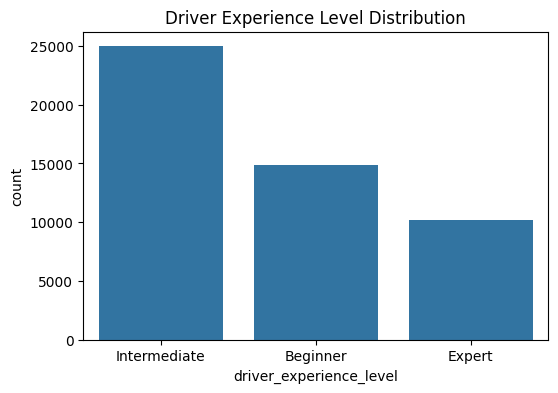

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x='weather_condition', data=data)
plt.title("Weather Condition Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x='driver_experience_level', data=data)
plt.title("Driver Experience Level Distribution")
plt.show()

### Feature vs Target (Scatterplots)

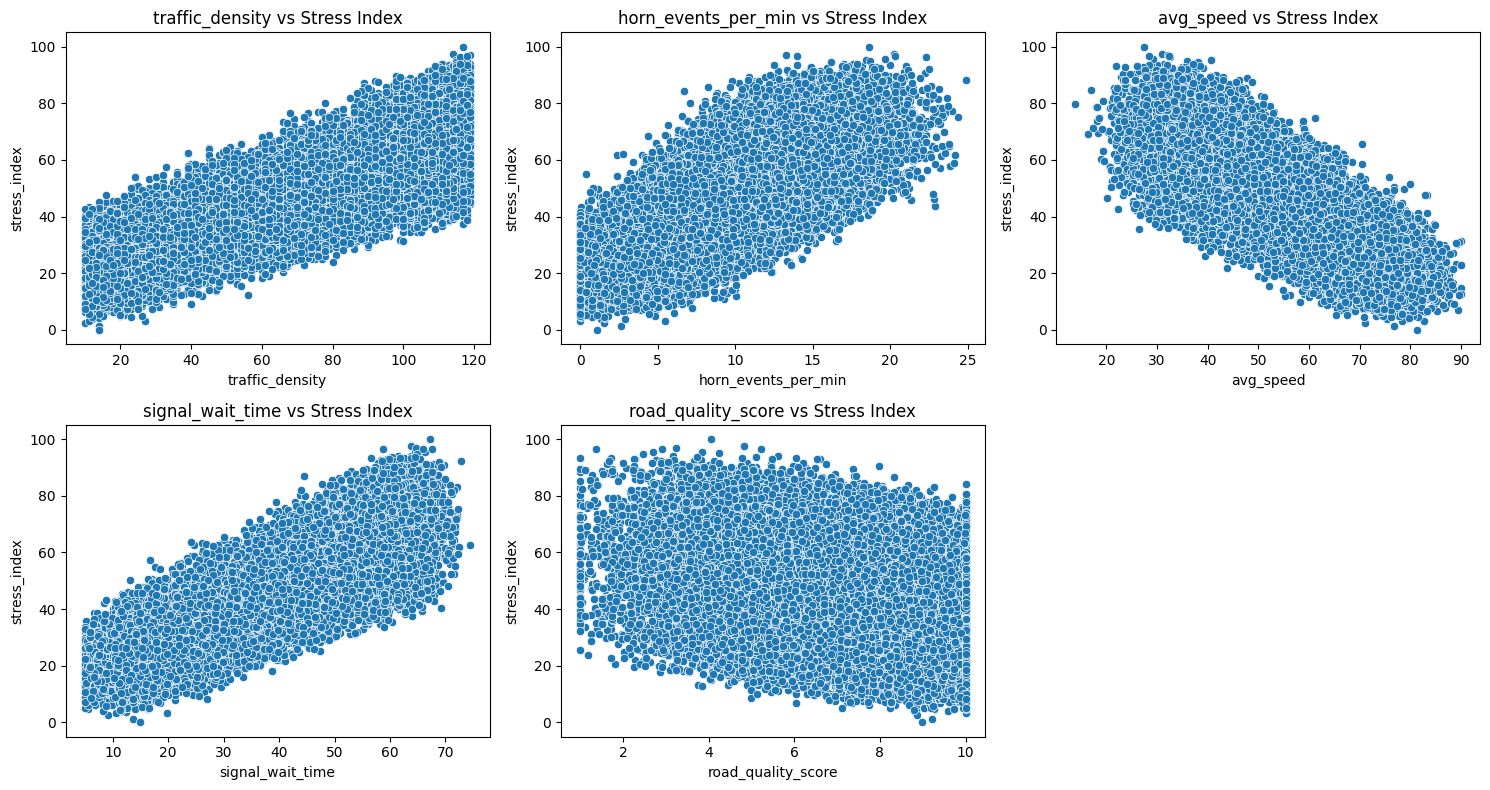

In [14]:
plt.figure(figsize=(15,8))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)   # 2 rows, 3 columns
    sns.scatterplot(x=data[col], y=data['stress_index'])
    plt.title(f"{col} vs Stress Index")

plt.tight_layout()
plt.show()

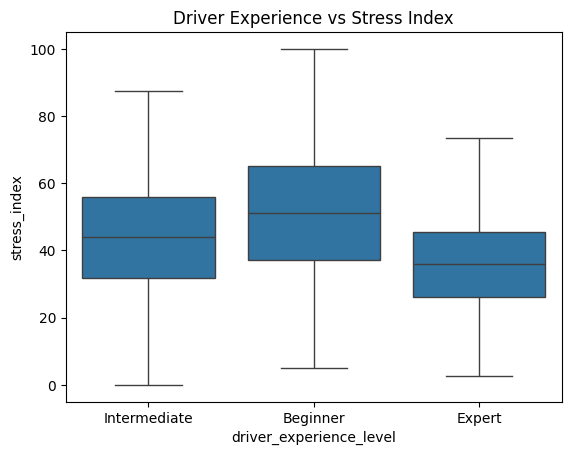

In [15]:
sns.boxplot(x='driver_experience_level', y='stress_index', data=data)
plt.title("Driver Experience vs Stress Index")
plt.show()

### Data Preprocessing

In [16]:
data.isnull().sum()

traffic_density            0
horn_events_per_min        0
avg_speed                  0
signal_wait_time           0
weather_condition          0
road_quality_score         0
driver_experience_level    0
stress_index               0
dtype: int64

In [17]:
data.duplicated().sum()

np.int64(0)

In [18]:
data.dtypes

traffic_density              int64
horn_events_per_min        float64
avg_speed                  float64
signal_wait_time           float64
weather_condition              str
road_quality_score         float64
driver_experience_level        str
stress_index               float64
dtype: object

### Encode Categorical Variables

In [19]:
le1=LabelEncoder()
le2=LabelEncoder()

data['weather_condition']=le1.fit_transform(data['weather_condition'])
data['driver_experience_level']=le2.fit_transform(data['driver_experience_level'])

In [20]:
data

,traffic_density,horn_events_per_min,avg_speed,signal_wait_time,weather_condition,road_quality_score,driver_experience_level,stress_index
0,112,12.93,28.61,56.58,1,7.31,2,68.37
1,61,7.43,54.22,35.64,3,8.78,0,47.14
2,102,11.07,41.42,54.61,0,8.34,2,55.02
3,24,1.54,69.86,16.09,0,6.29,1,22.71
4,116,11.60,33.01,62.51,0,8.19,1,49.91
...,...,...,...,...,...,...,...,...
49995,19,3.65,74.20,21.97,0,5.96,2,27.16
49996,72,12.05,61.39,44.49,1,3.29,2,57.83
49997,11,0.00,69.61,14.27,0,6.88,0,31.10
49998,45,9.87,66.66,28.47,0,5.82,2,33.20


In [21]:
c=data.corr()
c

,traffic_density,horn_events_per_min,avg_speed,signal_wait_time,weather_condition,road_quality_score,driver_experience_level,stress_index
traffic_density,1.000000,0.798583,-0.930653,0.982729,-0.003926,-0.003114,0.004791,0.852951
horn_events_per_min,0.798583,1.000000,-0.744490,0.785006,0.138823,-0.244160,0.010937,0.763327
avg_speed,-0.930653,-0.744490,1.000000,-0.914529,0.001912,0.006417,-0.001872,-0.811367
signal_wait_time,0.982729,0.785006,-0.914529,1.000000,-0.003375,-0.003983,0.005721,0.845248
weather_condition,-0.003926,0.138823,0.001912,-0.003375,1.000000,-0.008126,0.007449,0.012005
road_quality_score,-0.003114,-0.244160,0.006417,-0.003983,-0.008126,1.000000,-0.009692,-0.249190
driver_experience_level,0.004791,0.010937,-0.001872,0.005721,0.007449,-0.009692,1.000000,-0.162254
stress_index,0.852951,0.763327,-0.811367,0.845248,0.012005,-0.249190,-0.162254,1.000000


### Correlation Heatmap

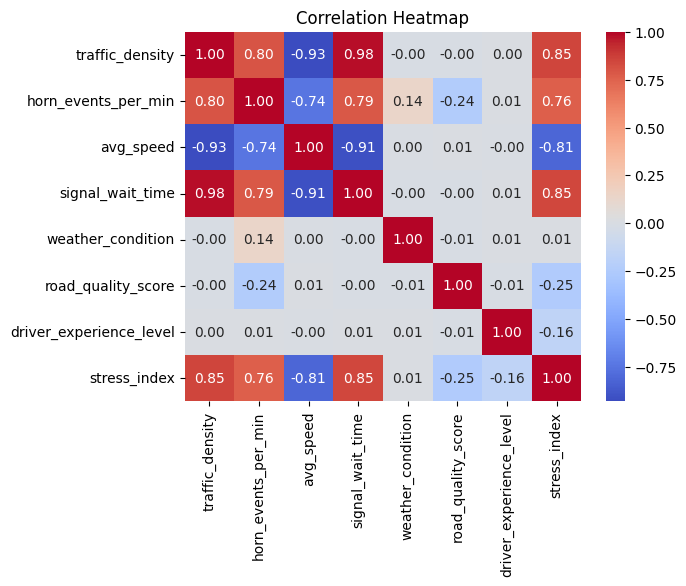

In [22]:
sns.heatmap(c, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


### Outlier Detection (Boxplots)

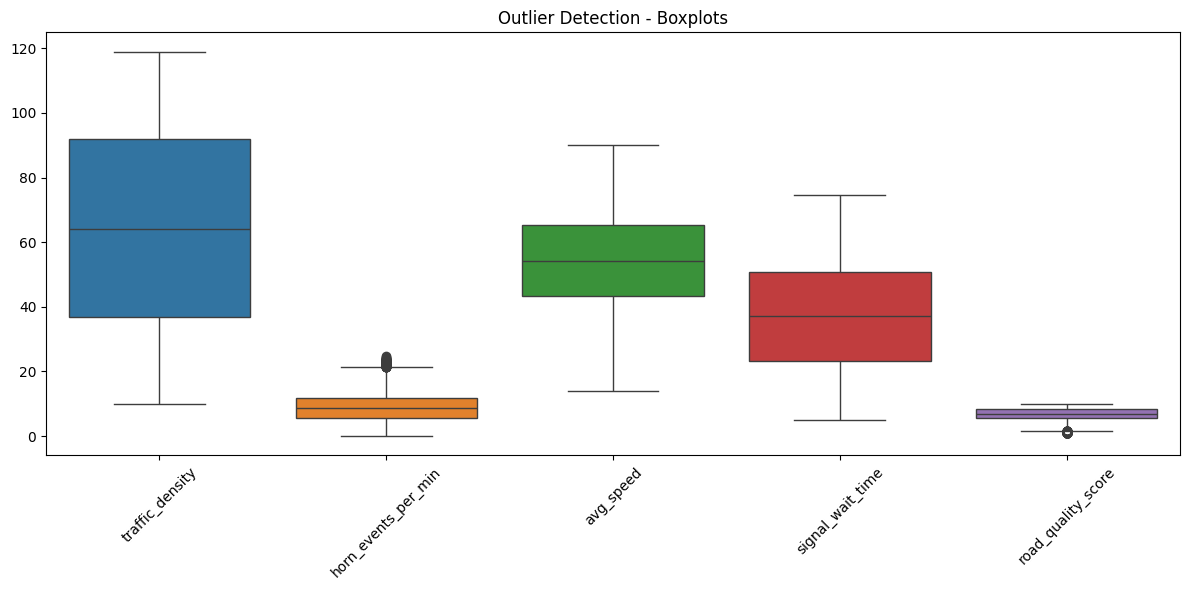

In [23]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=data[numerical_cols])
plt.title("Outlier Detection - Boxplots")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### IQR Method

In [24]:
numerical_cols = ['traffic_density', 'horn_events_per_min', 'avg_speed', 
                  'signal_wait_time','road_quality_score']

for col in numerical_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_count = ((data[col] < lower) | (data[col] > upper)).sum()
    print(f"{col}: {outlier_count} outliers")

traffic_density: 0 outliers
horn_events_per_min: 102 outliers
avg_speed: 0 outliers
signal_wait_time: 0 outliers
road_quality_score: 156 outliers


In [25]:
outlier_cols = ['horn_events_per_min','road_quality_score'] 

for col in outlier_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    data = data[(data[col] >= lower) & (data[col] <= upper)]

print("Outliers Removed Successfully!")
print("New Dataset Shape:", data.shape)

Outliers Removed Successfully!
New Dataset Shape: (49739, 8)


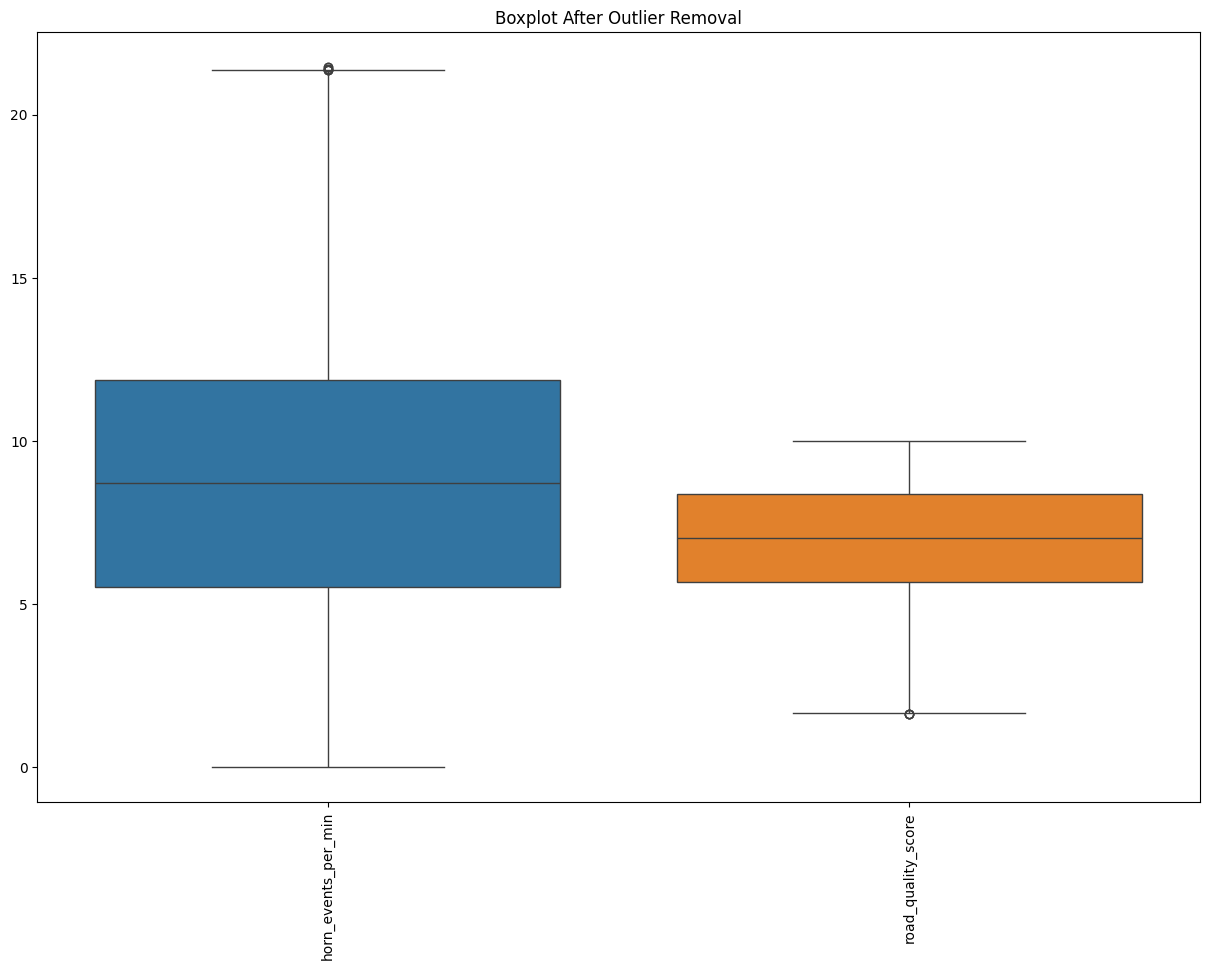

In [26]:
plt.figure(figsize=(15,10))
sns.boxplot(data=data[outlier_cols])
plt.title("Boxplot After Outlier Removal")
plt.xticks(rotation=90)
plt.show()

### Separate Features and Target

In [27]:
x=data.drop('stress_index',axis=1)
y=data[['stress_index']]

In [28]:
x

,traffic_density,horn_events_per_min,avg_speed,signal_wait_time,weather_condition,road_quality_score,driver_experience_level
0,112,12.93,28.61,56.58,1,7.31,2
1,61,7.43,54.22,35.64,3,8.78,0
2,102,11.07,41.42,54.61,0,8.34,2
3,24,1.54,69.86,16.09,0,6.29,1
4,116,11.60,33.01,62.51,0,8.19,1
...,...,...,...,...,...,...,...
49995,19,3.65,74.20,21.97,0,5.96,2
49996,72,12.05,61.39,44.49,1,3.29,2
49997,11,0.00,69.61,14.27,0,6.88,0
49998,45,9.87,66.66,28.47,0,5.82,2


In [29]:
y

,stress_index
0,68.37
1,47.14
2,55.02
3,22.71
4,49.91
...,...
49995,27.16
49996,57.83
49997,31.10
49998,33.20


### Train-Test Split

In [30]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [31]:
data.shape

(49739, 8)

### Scaling

In [32]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled  = scaler.transform(x_test)

### Linear Regression

In [33]:
lr=linear_model.LinearRegression()
lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [34]:
y_pred_lr=lr.predict(x_test)

In [35]:
y_pred_train_lr=lr.predict(x_train)

In [36]:
print('r2_score_lr_test:')
lr_test=r2_score(y_test,y_pred_lr)
lr_test

r2_score_lr_test:


0.8210728467256019

In [37]:
print('r2_score_lr_train :')
lr_train=r2_score(y_train,y_pred_train_lr)
lr_train

r2_score_lr_train :


0.8211591175794457

### DecisionTree

In [38]:
dt=DecisionTreeRegressor(max_depth=5)
dt

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_le

In [39]:
dt.fit(x_train,y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_le

In [40]:
y_pred_dt=dt.predict(x_test)

In [41]:
y_pred_train_dt=dt.predict(x_train)

In [42]:
print('r2_score_dt_test:')
dt_test=r2_score(y_test,y_pred_dt)
dt_test

r2_score_dt_test:


0.8544713668475805

In [43]:
print('r2_score_dt_train :')
dt_train=r2_score(y_train,y_pred_train_dt)
dt_train

r2_score_dt_train :


0.8600065963143502

### RandomForest

In [44]:
rf=RandomForestRegressor(random_state=42)

In [45]:
rf.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [46]:
y_pred_rf=rf.predict(x_test)

In [47]:
y_pred_train_rf=rf.predict(x_train)

In [48]:
print('r2_score_rf_test:')
rf_test=r2_score(y_test,y_pred_rf)
rf_test

r2_score_rf_test:


0.901489633232618

In [49]:
print('r2_score_rf_train :')
rf_train=r2_score(y_train,y_pred_train_rf)
rf_train

r2_score_rf_train :


0.9864689730888043

### KNN

In [50]:
knn = KNeighborsRegressor()
knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [51]:
y_pred_knn = knn.predict(X_test_scaled)

In [52]:
y_pred_train_knn=knn.predict(X_train_scaled)

In [53]:
print('r2_score_knn_test:')
knn_test=r2_score(y_test,y_pred_knn)
knn_test

r2_score_knn_test:


0.8902763600809995

In [54]:
print('r2_score_knn_train :')
knn_train=r2_score(y_train,y_pred_train_knn)
knn_train

r2_score_knn_train :


0.9279350894927256

### SVR

In [55]:
svr = SVR(kernel='rbf',C=100,epsilon=0.1) 
svr.fit(X_train_scaled, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [56]:
y_pred_svr = svr.predict(X_test_scaled)

In [57]:
y_pred_train_svr=svr.predict(X_train_scaled)

In [58]:
print('r2_score_svr_test:')
svr_test=r2_score(y_test,y_pred_svr)
svr_test

r2_score_svr_test:


0.9079010552752039

In [59]:
print('r2_score_svr_train :')
svr_train=r2_score(y_train,y_pred_train_svr)
svr_train

r2_score_svr_train :


0.9134375789948009

### AdaBoost

In [60]:
ada = AdaBoostRegressor(random_state=42)                                                                            
ada.fit(x_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.If ``None``, then the base estimator is:class:`~sklearn.tree.DecisionTreeRegressor` initialized with`max_depth=3`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each regressor at each boosting iteration. A higherlearning rate increases the contribution of each regressor. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"loss loss: {'linear', 'square', 'exponential'}, default='linear'The loss function to use when updating the weights after eachboosting iteration.",'linear'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.In addition, it controls the bootstrap of the weights used to train the`estimator` at each boosting iteration.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [61]:
y_pred_ada = ada.predict(x_test)

In [62]:
y_pred_train_ada=ada.predict(x_train)

In [63]:
print('r2_score_ada_test:')
ada_test=r2_score(y_test,y_pred_ada)
ada_test

r2_score_ada_test:


0.8773562143900127

In [64]:
print('r2_score_ada_train :')
ada_train=r2_score(y_train,y_pred_train_ada)
ada_train

r2_score_ada_train :


0.8794521970687836

### GradientBoost

In [65]:
gbr = GradientBoostingRegressor(random_state=42) 
gbr.fit(x_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [66]:
y_pred_gbr = gbr.predict(x_test)

In [67]:
y_pred_train_gbr=gbr.predict(x_train)

In [68]:
print('r2_score_gbr_test:')
gbr_test=r2_score(y_test,y_pred_gbr)
gbr_test

r2_score_gbr_test:


0.9070844347482567

In [69]:
print('r2_score_gbr_train :')
gbr_train=r2_score(y_train,y_pred_train_gbr)
gbr_train

r2_score_gbr_train :


0.912220475513558

### XGBoost

In [70]:
xgb = XGBRegressor(random_state=42)

In [71]:
xgb.fit(x_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [72]:
y_pred_xgb= xgb.predict(x_test)

In [73]:
y_pred_train_xgb=xgb.predict(x_train)

In [74]:
print('r2_score_xgb_test:')
xgb_test=r2_score(y_test,y_pred_xgb)
xgb_test

r2_score_xgb_test:


0.9035340547561646

In [75]:
print('r2_score_xgb_train :')
xgb_train=r2_score(y_train,y_pred_train_xgb)
xgb_train

r2_score_xgb_train :


0.9304687976837158

### Initial Performance

In [76]:
tb=pd.DataFrame()
tb['model']=pd.Series(['lr','dt','rf','knn','svr','ada','gbr','xgb'])
tb['test_score']=pd.Series([lr_test,dt_test,rf_test,knn_test,svr_test,ada_test,gbr_test,xgb_test])
tb['train_score']=pd.Series([lr_train,dt_train,rf_train,knn_train,svr_train,ada_train,gbr_train,xgb_train])
tb

,model,test_score,train_score
0,lr,0.821073,0.821159
1,dt,0.854471,0.860007
2,rf,0.901490,0.986469
3,knn,0.890276,0.927935
4,svr,0.907901,0.913438
5,ada,0.877356,0.879452
6,gbr,0.907084,0.912220
7,xgb,0.903534,0.930469


In [77]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("R2 Score:", r2_score(y_test, y_pred_svr))
print("MAE:", mean_absolute_error(y_test, y_pred_svr))
print("MSE:", mean_squared_error(y_test, y_pred_svr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_svr)))

R2 Score: 0.9079010552752039
MAE: 3.966222996556459
MSE: 24.67405664065064
RMSE: 4.967298726737767


In [78]:
models = {

    "Linear Regression": {
        "model": LinearRegression(),
        "params": {}
    },

    "Decision Tree": {
        "model": DecisionTreeRegressor(random_state=42),
        "params": {
            "max_depth": [5, 10, 20],
            "min_samples_split": [2, 5, 10]
        }
    },

    "Random Forest": {
        "model": RandomForestRegressor(random_state=42),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [10, 20],
            "min_samples_split": [2, 5]
        }
    },

    "KNN Regressor": {
        "model": KNeighborsRegressor(),
        "params": {
            "n_neighbors": [3, 5, 7]
        }
    },

    "SVR": {
        "model": SVR(),
        "params": {
            "C": [1, 10],
            "gamma": ["scale", "auto"]
        }
    },

    "AdaBoost": {
        "model": AdaBoostRegressor(random_state=42),
        "params": {
            "n_estimators": [50, 100],
            "learning_rate": [0.05, 0.1, 1]
        }
    },

    "Gradient Boosting": {
        "model": GradientBoostingRegressor(random_state=42),
        "params": {
            "n_estimators": [100, 200],
            "learning_rate": [0.05, 0.1],
            "max_depth": [3, 5]
        }
    },

    "XGBoost": {
        "model": XGBRegressor(random_state=42),
        "params": {
            "n_estimators": [100, 200],
            "learning_rate": [0.05, 0.1],
            "max_depth": [3, 5]
        }
    }
}


# Store results
results = []

# Hyperparameter tuning loop
for model_name, model_info in models.items():

    print(f"\n Tuning {model_name}...")

    grid = GridSearchCV(
        estimator=model_info["model"],
        param_grid=model_info["params"],
        cv=3,
        scoring="r2",
        n_jobs=-1
    )

    grid.fit(x_train, y_train)

    # Best model prediction
    best_model = grid.best_estimator_
    y_pred = best_model.predict(x_test)

    # Score
    score = r2_score(y_test, y_pred)

    results.append({
        "Model": model_name,
        "Best Parameters": grid.best_params_,
        "R2 Score": score
    })

    print(" Best Params:", grid.best_params_)
    print(" R2 Score:", score)


# Convert results into DataFrame
results_df = pd.DataFrame(results)

print("\n Final Model Comparison:")
print(results_df.sort_values(by="R2 Score", ascending=False))


 Tuning Linear Regression...
 Best Params: {}
 R2 Score: 0.8210728467256019

 Tuning Decision Tree...
 Best Params: {'max_depth': 10, 'min_samples_split': 10}
 R2 Score: 0.8907090993696104

 Tuning Random Forest...
 Best Params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
 R2 Score: 0.905838516931743

 Tuning KNN Regressor...
 Best Params: {'n_neighbors': 7}
 R2 Score: 0.7921735293832645

 Tuning SVR...
 Best Params: {'C': 10, 'gamma': 'scale'}
 R2 Score: 0.820746870946606

 Tuning AdaBoost...
 Best Params: {'learning_rate': 1, 'n_estimators': 100}
 R2 Score: 0.8847064905832389

 Tuning Gradient Boosting...
 Best Params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}
 R2 Score: 0.907600155004869

 Tuning XGBoost...
 Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
 R2 Score: 0.9076196551322937

 Final Model Comparison:
               Model                                    Best Parameters  \
7            XGBoost  {'learning_rat

## Train Final Model with Best Parameters

## LINEAR REGRESSION

In [79]:
lr = linear_model.LinearRegression()
lr.fit(x_train, y_train)

y_pred_lr = lr.predict(x_test)
y_pred_train_lr = lr.predict(x_train)

lr_test_r=r2_score(y_test, y_pred_lr)
lr_train_r=r2_score(y_train, y_pred_train_lr)

print("Linear Regression Test Score:",lr_test_r )
print("Linear Regression Train Score:",lr_train_r )

Linear Regression Test Score: 0.8210728467256019
Linear Regression Train Score: 0.8211591175794457


## DECISION TREE

In [80]:
dt = DecisionTreeRegressor(max_depth=10, min_samples_split=10)

dt.fit(x_train, y_train)

y_pred_dt = dt.predict(x_test)
y_pred_train_dt = dt.predict(x_train)

dt_test_r = r2_score(y_test, y_pred_dt)
dt_train_r = r2_score(y_train, y_pred_train_dt)

print("Decision Tree Test Score:", dt_test_r)
print("Decision Tree Train Score:", dt_train_r)

Decision Tree Test Score: 0.8907090993696104
Decision Tree Train Score: 0.920381744921721


## RANDOM FOREST

In [81]:
rf=RandomForestRegressor(n_estimators=200,max_depth=10, min_samples_split= 5)

rf.fit(x_train,y_train)

y_pred_rf=rf.predict(x_test)
y_pred_train_rf=rf.predict(x_train)

rf_test_r = r2_score(y_test, y_pred_rf)
rf_train_r = r2_score(y_train, y_pred_train_rf)

print("Random Forest Test Score:", rf_test_r)
print("Random Forest Train Score:", rf_train_r)

Random Forest Test Score: 0.9057175566051737
Random Forest Train Score: 0.928336475902957


## K NEAREST NEIGHBOUR (KNN)

In [82]:
knn = KNeighborsRegressor(n_neighbors=7)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
y_pred_train_knn=knn.predict(X_train_scaled)

knn_test_r = r2_score(y_test,y_pred_knn)
knn_train_r = r2_score(y_train,y_pred_train_knn)

print('KNN Test Score:',knn_test_r)
print('KNN Train Score:',knn_train_r)

KNN Test Score: 0.8945894403464372
KNN Train Score: 0.9228159721399996


## SVR

In [83]:
svr = SVR(C=10,gamma='scale')

svr.fit(X_train_scaled, y_train)

y_pred_svr = svr.predict(X_test_scaled)
y_pred_train_svr=svr.predict(X_train_scaled)

svr_test_r = r2_score(y_test,y_pred_svr)
svr_train_r = r2_score(y_train,y_pred_train_svr)

print('SVR Test Score:',svr_test_r)
print('SVR Train Score:',svr_train_r)

SVR Test Score: 0.9084250004078561
SVR Train Score: 0.9124488777784843


## ADABOOST

In [84]:
ada = AdaBoostRegressor(n_estimators=100,learning_rate=1)  

ada.fit(x_train, y_train)

y_pred_ada = ada.predict(x_test)
y_pred_train_ada=ada.predict(x_train)

ada_test_r = r2_score(y_test,y_pred_ada)
ada_train_r = r2_score(y_train,y_pred_train_ada)

print('AdaBoost Test Score:',ada_test_r)
print('AdaBoost Train Score:',ada_train_r)

AdaBoost Test Score: 0.8885088520703521
AdaBoost Train Score: 0.8901927743633777


## GRADIENTBOOSTING

In [85]:
gbr = GradientBoostingRegressor(n_estimators=200,learning_rate=0.05,max_depth=3)     
                                          
gbr.fit(x_train, y_train)

y_pred_gbr = gbr.predict(x_test)
y_pred_train_gbr=gbr.predict(x_train)

gbr_test_r = r2_score(y_test,y_pred_gbr)
gbr_train_r = r2_score(y_train,y_pred_train_gbr)

print('GradientBoosting Test Score:',gbr_test_r)
print('GradientBoosting Train Score::',gbr_train_r)

GradientBoosting Test Score: 0.9074839643061012
GradientBoosting Train Score:: 0.9127925701217101


## XGBOOST

In [86]:
xgb = XGBRegressor(n_estimators=200,learning_rate=0.05,max_depth=3)

xgb.fit(x_train, y_train)

y_pred_xgb= xgb.predict(x_test)
y_pred_train_xgb=xgb.predict(x_train)

xgb_test_r = r2_score(y_test,y_pred_xgb)
xgb_train_r = r2_score(y_train,y_pred_train_xgb)

print('XGBoost Test Score:',xgb_test_r)
print('XGBoost Train Score:',xgb_train_r)

XGBoost Test Score: 0.9074980020523071
XGBoost Train Score: 0.9126043319702148


In [87]:
tb=pd.DataFrame()
tb['model']=pd.Series(['lr','dt','rf','knn','svr','ada','gbr','xgb'])
tb['test_score']=pd.Series([lr_test_r,dt_test_r,rf_test_r,knn_test_r,svr_test_r,ada_test_r,gbr_test_r,xgb_test_r])
tb['train_score']=pd.Series([lr_train_r,dt_train_r,rf_train_r,knn_train_r,svr_train_r,ada_train_r,gbr_train_r,xgb_train_r])
tb

,model,test_score,train_score
0,lr,0.821073,0.821159
1,dt,0.890709,0.920382
2,rf,0.905718,0.928336
3,knn,0.894589,0.922816
4,svr,0.908425,0.912449
5,ada,0.888509,0.890193
6,gbr,0.907484,0.912793
7,xgb,0.907498,0.912604


In [ ]:
tb_sorted = tb.sort_values('test_score', ascending=True)

tb_sorted.plot(x='model', y=['train_score', 'test_score'], 
               kind='barh', figsize=(9, 5), color=['steelblue', 'coral'])

plt.xlabel('R² Score')
plt.title('Model Comparison - Train vs Test Score')
plt.xlim(0.75, 1.0)
plt.tight_layout()
plt.show()

In [ ]:
import joblib
joblib.dump(svr,    r'C:/Users/janus/traffic_stress.pkl')
joblib.dump(scaler, r'C:/Users/janus/svr_scaler.pkl')
joblib.dump(le1,    r'C:/Users/janus/le1.pkl')
joblib.dump(le2,    r'C:/Users/janus/le2.pkl')
print("All saved!")